# Maintenance Prédictive – Machine Learning
**Dataset :** `industrial_machine_maintenance.csv`  
**Objectif principal :** Prédire `failure_within_24h` (classification binaire)  
**Objectifs secondaires :** Prédire `failure_type` (multi-classes) et `rul_hours` (régression)

## 1. Importation des librairies

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Librairies chargées ✓')

Librairies chargées ✓


## 2. Chargement des données

In [63]:
df = pd.read_csv('industrial_machine_maintenance.csv', parse_dates=['timestamp'])
print(f'Shape : {df.shape}')
df.head()

Shape : (24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[us]
 1   machine_id               24042 non-null  int64         
 2   machine_type             24042 non-null  str           
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  str           
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  float64       
 12  failure_within_24h       24042 non-null  in

In [65]:
df.describe()

,timestamp,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,2024-01-08 00:06:30.111721,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
min,2024-01-01 00:00:00,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,2024-01-04 12:24:13.750000,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,2024-01-08 00:11:30,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,2024-01-11 13:24:32.500000,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,2024-01-14 23:59:38,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000
std,NaN,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887


## 3. Analyse exploratoire (EDA)

Valeurs manquantes :
vibration_rms        1000
pressure_level        924
temperature_motor     834
current_phase_avg     731
rpm                   533
dtype: int64


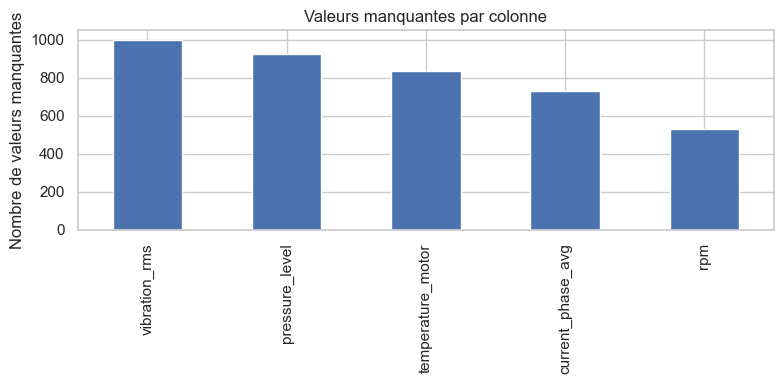

In [66]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Valeurs manquantes :')
print(missing)

if not missing.empty:
    missing.plot(kind='bar', figsize=(8, 4), title='Valeurs manquantes par colonne')
    plt.ylabel('Nombre de valeurs manquantes')
    plt.tight_layout()
    plt.show()

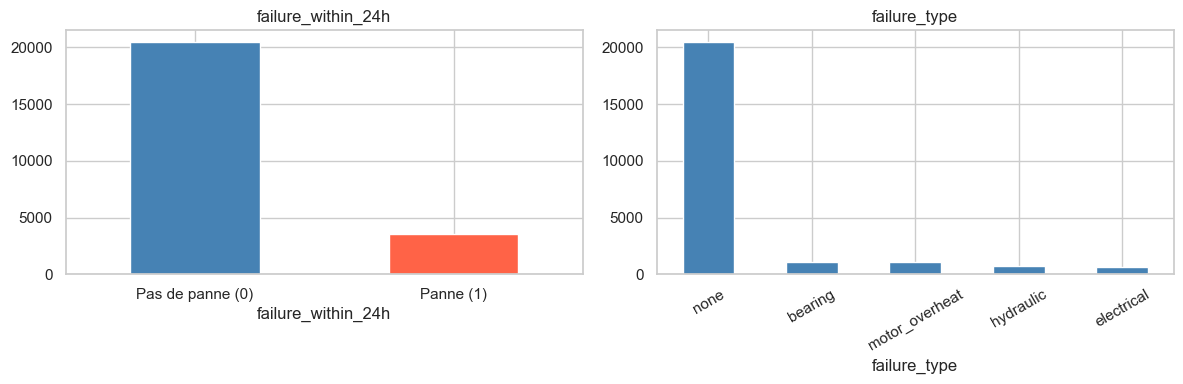

In [67]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['failure_within_24h'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('failure_within_24h')
axes[0].set_xticklabels(['Pas de panne (0)', 'Panne (1)'], rotation=0)

df['failure_type'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('failure_type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

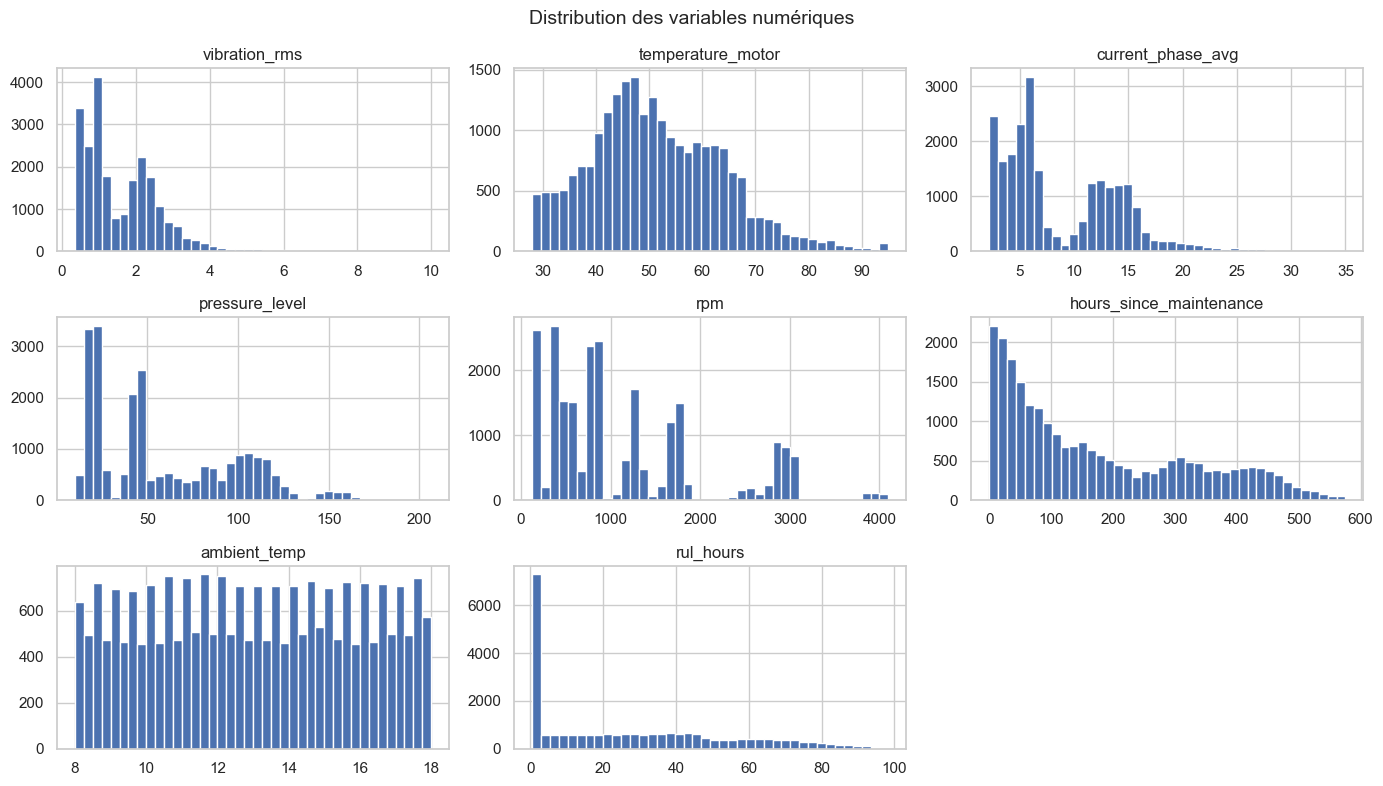

In [68]:
# Distribution des variables numériques
num_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
            'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours']

df[num_cols].hist(figsize=(14, 8), bins=40, edgecolor='white')
plt.suptitle('Distribution des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

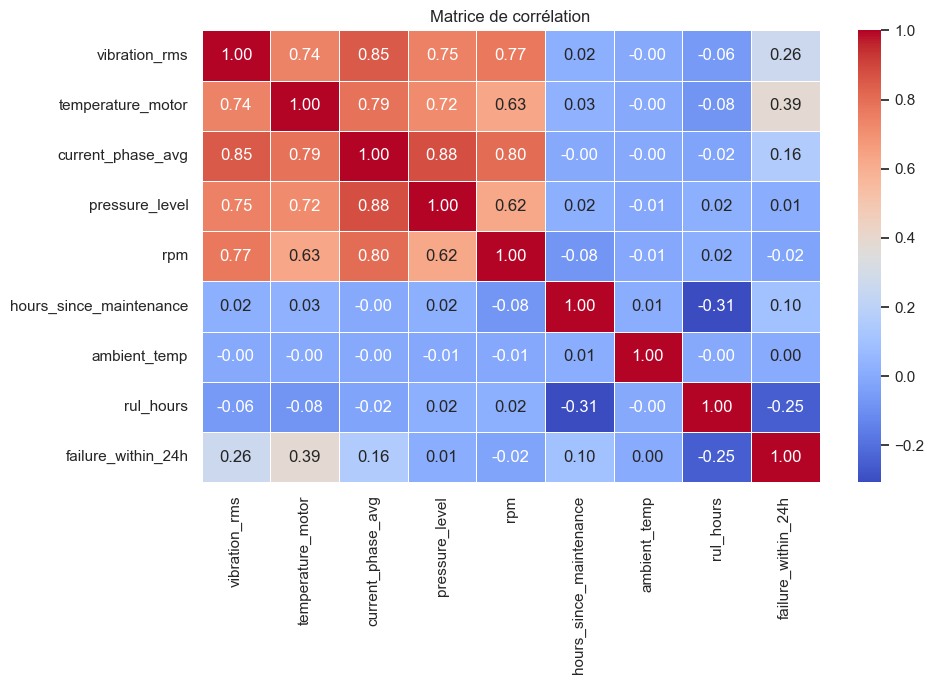

In [69]:
# Matrice de corrélation
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['failure_within_24h']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

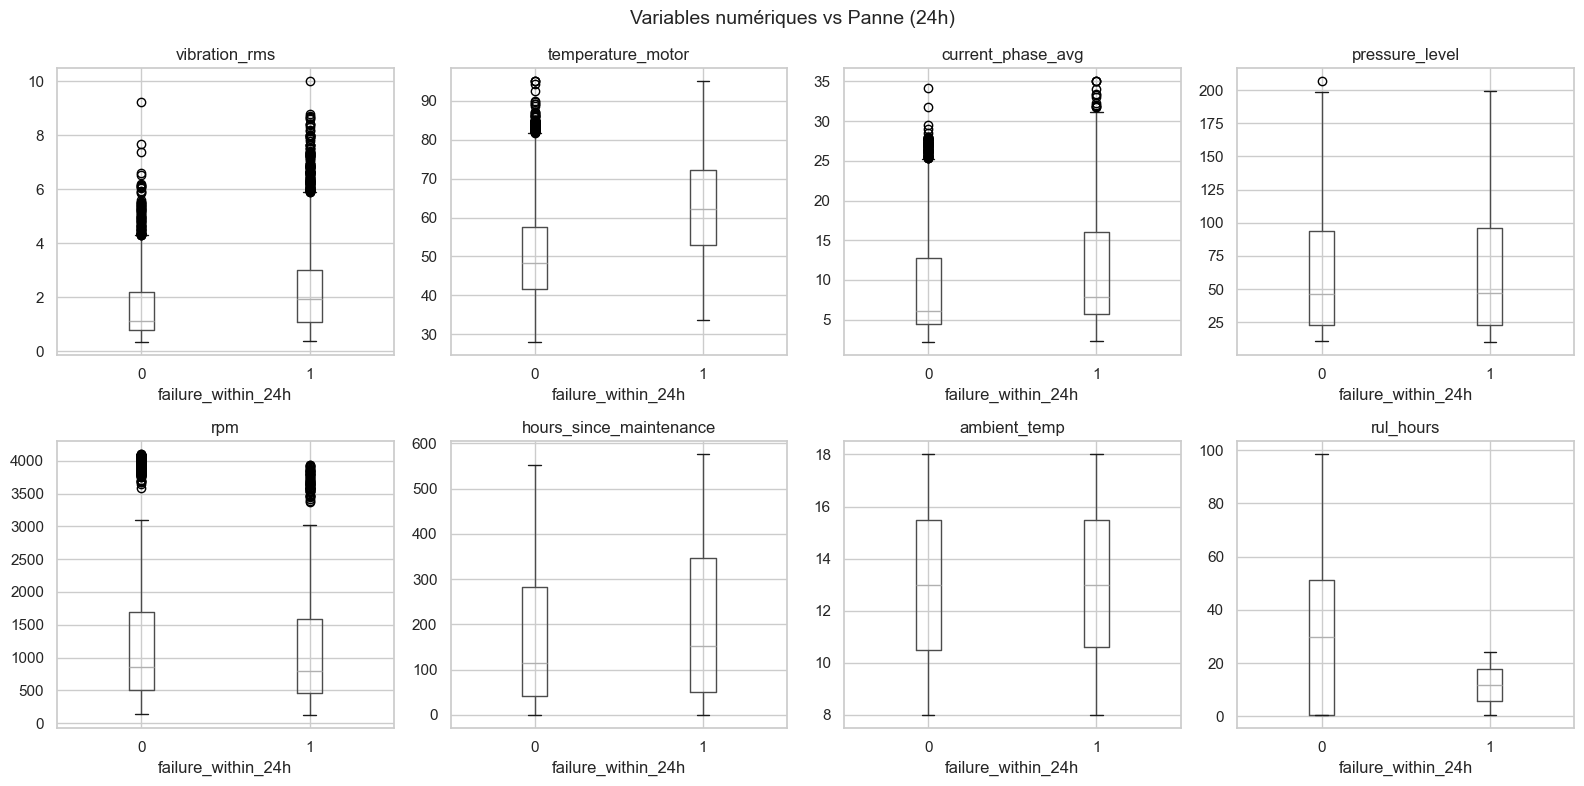

In [70]:
# Boxplots : variables numériques vs failure_within_24h
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='failure_within_24h', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('failure_within_24h')

plt.suptitle('Variables numériques vs Panne (24h)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Préparation des données

In [71]:
# Feature engineering : extraction de features temporelles
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Encodage des variables catégorielles
le_type = LabelEncoder()
le_mode = LabelEncoder()

df['machine_type_enc'] = le_type.fit_transform(df['machine_type'].astype(str))
df['operating_mode_enc'] = le_mode.fit_transform(df['operating_mode'].astype(str))

print('Encodage terminé ✓')
print(f"machine_type mapping : {dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")
print(f"operating_mode mapping : {dict(zip(le_mode.classes_, le_mode.transform(le_mode.classes_)))}")

Encodage terminé ✓
machine_type mapping : {'CNC': np.int64(0), 'Compressor': np.int64(1), 'Pump': np.int64(2), 'Robotic Arm': np.int64(3)}
operating_mode mapping : {'idle': np.int64(0), 'normal': np.int64(1), 'peak': np.int64(2)}


In [72]:
# Sélection des features
FEATURES = [
    'vibration_rms', 'temperature_motor', 'current_phase_avg',
    'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp',
    'machine_type_enc', 'operating_mode_enc', 'hour', 'dayofweek', 'month'
]
TARGET = 'failure_within_24h'

X = df[FEATURES]
y = df[TARGET]

print(f'X shape : {X.shape}')
print(f'Taux de pannes : {y.mean():.2%}')

X shape : (24042, 12)
Taux de pannes : 14.81%


In [73]:
# Split train/test (80/20) stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')

Train : 19233 lignes | Test : 4809 lignes


## 5. Entraînement des modèles

In [74]:
# Définition des pipelines
models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                              scale_pos_weight=1, random_state=42, n_jobs=-1,
                              eval_metric='logloss'))
    ])
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | ROC-AUC CV = {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       | ROC-AUC CV = 0.9492 ± 0.0040
Random Forest             | ROC-AUC CV = 0.9948 ± 0.0006
XGBoost                   | ROC-AUC CV = 0.9970 ± 0.0005


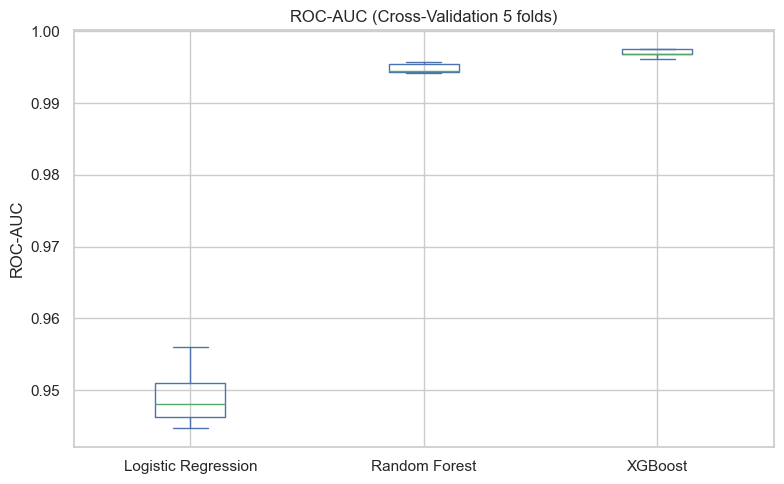

In [75]:
# Visualisation des scores CV
cv_df = pd.DataFrame(cv_results)
cv_df.plot(kind='box', figsize=(8, 5))
plt.title('ROC-AUC (Cross-Validation 5 folds)')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

## 6. Évaluation sur le jeu de test

In [76]:
# Entraînement final et évaluation
trained_models = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f'\n=== {name} (ROC-AUC test = {auc:.4f}) ===')
    print(classification_report(y_test, y_pred, target_names=['Pas de panne', 'Panne']))


=== Logistic Regression (ROC-AUC test = 0.9515) ===
              precision    recall  f1-score   support

Pas de panne       0.98      0.91      0.94      4097
       Panne       0.62      0.88      0.73       712

    accuracy                           0.90      4809
   macro avg       0.80      0.89      0.83      4809
weighted avg       0.92      0.90      0.91      4809


=== Random Forest (ROC-AUC test = 0.9954) ===
              precision    recall  f1-score   support

Pas de panne       0.98      0.99      0.99      4097
       Panne       0.94      0.89      0.91       712

    accuracy                           0.98      4809
   macro avg       0.96      0.94      0.95      4809
weighted avg       0.98      0.98      0.98      4809


=== XGBoost (ROC-AUC test = 0.9973) ===
              precision    recall  f1-score   support

Pas de panne       0.99      0.99      0.99      4097
       Panne       0.95      0.94      0.94       712

    accuracy                           0.

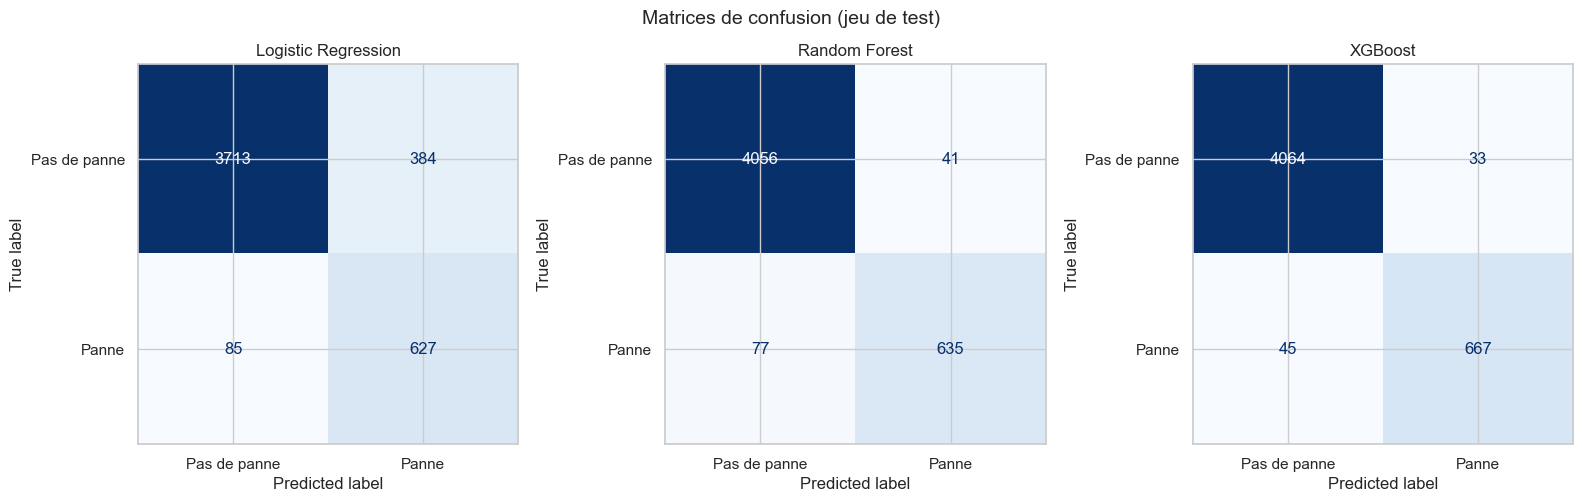

In [77]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pipe) in zip(axes, trained_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pas de panne', 'Panne'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Matrices de confusion (jeu de test)', fontsize=14)
plt.tight_layout()
plt.show()

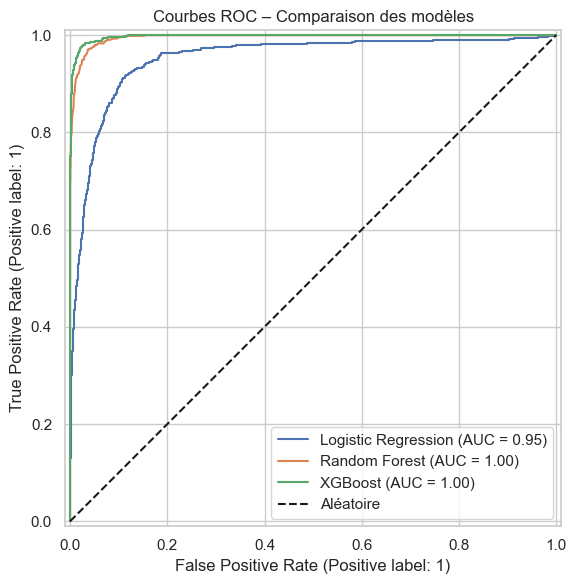

In [78]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 6))

for name, pipe in trained_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax.set_title('Courbes ROC – Comparaison des modèles')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Importance des features (Random Forest)

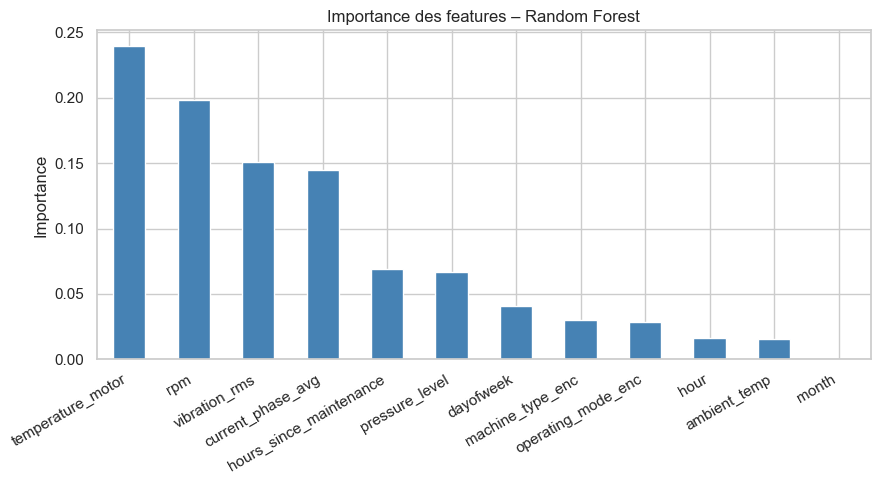

temperature_motor          0.239611
rpm                        0.198397
vibration_rms              0.150672
current_phase_avg          0.144617
hours_since_maintenance    0.069272
pressure_level             0.067100
dayofweek                  0.040503
machine_type_enc           0.030047
operating_mode_enc         0.028216
hour                       0.016097
ambient_temp               0.015467
month                      0.000000
dtype: float64


In [79]:
rf_pipe = trained_models['Random Forest']
importances = rf_pipe.named_steps['clf'].feature_importances_

feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importance des features – Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp)

In [80]:
## 8. Sauvegarde des modèles en Joblib
import joblib

model_filenames = {
    'Logistic Regression': 'logistic_regression_failure_24h.joblib',
    'Random Forest':       'random_forest_failure_24h.joblib',
    'XGBoost':             'xgboost_failure_24h.joblib',
}

for name, filename in model_filenames.items():
    joblib.dump(trained_models[name], filename)
    model_loaded = joblib.load(filename)
    y_prob_check = model_loaded.predict_proba(X_test)[:, 1]
    auc_check = roc_auc_score(y_test, y_prob_check)
    print(f"{name:25s} → {filename}  (ROC-AUC : {auc_check:.4f} ✓)")

Logistic Regression       → logistic_regression_failure_24h.joblib  (ROC-AUC : 0.9515 ✓)
Random Forest             → random_forest_failure_24h.joblib  (ROC-AUC : 0.9954 ✓)
XGBoost                   → xgboost_failure_24h.joblib  (ROC-AUC : 0.9973 ✓)


## 8. Conclusion et pistes d'amélioration

### Résumé
- Trois modèles entraînés : **Logistic Regression**, **Random Forest**, **Gradient Boosting**
- Métrique principale : **ROC-AUC** (adapté aux datasets déséquilibrés)
- Les features les plus discriminantes sont identifiées via le Random Forest

### Pistes d'amélioration
1. **Optimisation des hyperparamètres** : `GridSearchCV` ou `Optuna`
2. **Gestion du déséquilibre** : SMOTE, sous-échantillonnage, `class_weight`
3. **Features temporelles avancées** : rolling mean/std sur la vibration et la température
4. **Régression sur `rul_hours`** : Random Forest Regressor, XGBoost Regressor
5. **Classification multi-classes** : prédire `failure_type` avec un modèle multi-label

In [81]:
# Vérification : rechargement et test des 3 modèles sauvegardés
for name, filename in model_filenames.items():
    m = joblib.load(filename)
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} (rechargé depuis {filename}) ===")
    print(classification_report(y_test, y_pred, target_names=['Pas de panne', 'Panne']))
    print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")


=== Logistic Regression (rechargé depuis logistic_regression_failure_24h.joblib) ===
              precision    recall  f1-score   support

Pas de panne       0.98      0.91      0.94      4097
       Panne       0.62      0.88      0.73       712

    accuracy                           0.90      4809
   macro avg       0.80      0.89      0.83      4809
weighted avg       0.92      0.90      0.91      4809

ROC-AUC : 0.9515

=== Random Forest (rechargé depuis random_forest_failure_24h.joblib) ===
              precision    recall  f1-score   support

Pas de panne       0.98      0.99      0.99      4097
       Panne       0.94      0.89      0.91       712

    accuracy                           0.98      4809
   macro avg       0.96      0.94      0.95      4809
weighted avg       0.98      0.98      0.98      4809

ROC-AUC : 0.9954

=== XGBoost (rechargé depuis xgboost_failure_24h.joblib) ===
              precision    recall  f1-score   support

Pas de panne       0.99      0.99  